# Complex EDA — Financial News & Stock Price Dataset

This notebook performs a thorough exploratory data analysis of `news_prices_full_processed_with_target_v2.parquet`.

**Structure**
1. Setup & data loading
2. Missing values audit + column pruning
3. Target variable deep-dive
4. Temporal patterns
5. Ticker & sector analysis
6. Sentiment & emotion analysis
7. Text-length signals
8. Price feature correlations
9. Key insights summary

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── aesthetics ────────────────────────────────────────────────────────────────
PALETTE   = 'coolwarm'
C_POS     = '#2ecc71'   # green  – used for positive / up moves
C_NEG     = '#e74c3c'   # red    – used for negative / down moves
C_NEUTRAL = '#3498db'   # blue   – neutral / general
C_ACCENT  = '#9b59b6'   # purple – accent

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

# ── configurable threshold ────────────────────────────────────────────────────
# Drop columns whose NaN rate exceeds this value  ← CHANGE AS NEEDED
K = 0.2

## 1. Load data

In [7]:
df = pd.read_parquet('data_sample/news_prices_full_processed_with_target_v2.parquet')
print(f'Shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.head(3)

Shape: (84658, 156)
Date range: 2017-01-04 → 2023-12-27


,date,prev_date,future_date,title,description,maintext,ticker,prev_day_price,curr_day_price,next_day_price,...,price_position_28d,hist_volatility_approx,hist_volatility_7d,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_end,day_of_week_num
0,2019-01-22,2019-01-21,2019-01-23,UBS Warns on Client Activity After $13 Billion...,Withdrawals at the Zurich-based bank’s key glo...,(Bloomberg) -- UBS Group AG warned client acti...,C,63.12,61.85,62.13,...,1.788574,0.049656,0.051859,1,1,4,0,0,0,1
1,2019-10-31,2019-10-30,2019-11-01,Wayfair Plunges as Forecast Miss Heightens Gro...,(Bloomberg) -- Wayfair Inc. plunged near its l...,(Bloomberg) -- Wayfair Inc. plunged near its l...,C,72.97,71.86,73.84,...,2.501554,0.036507,0.043897,10,4,44,0,1,0,3
2,2019-01-15,2019-01-14,2019-01-16,TSMC's $43 Billion Wipeout Will Only Get Worse...,TSMC will struggle to plug the hole left by Ap...,(Bloomberg) -- The worst isn’t over yet for Ta...,C,58.93,61.38,62.19,...,3.408366,0.066905,0.062490,1,1,3,0,0,0,1


In [8]:
df.dtypes.to_frame('dtype').assign(example=df.iloc[0].astype(str)).head(30)

,dtype,example
date,datetime64[ns],2019-01-22 00:00:00
prev_date,datetime64[ns],2019-01-21 00:00:00
future_date,datetime64[ns],2019-01-23 00:00:00
title,object,UBS Warns on Client Activity After $13 Billion...
description,object,Withdrawals at the Zurich-based bank’s key glo...
maintext,object,(Bloomberg) -- UBS Group AG warned client acti...
ticker,object,C
prev_day_price,float64,63.12
curr_day_price,float64,61.85
next_day_price,float64,62.13


## 2. Missing values audit

In [9]:
nan_df = (
    df.isnull().sum()
    .to_frame('n_missing')
    .assign(nan_rate=lambda x: x['n_missing'] / len(df))
    .sort_values('nan_rate', ascending=False)
)
nan_df['above_threshold'] = nan_df['nan_rate'] > K
print(f'NaN threshold K = {K}')
print(f'Columns above threshold: {nan_df["above_threshold"].sum()}')
nan_df

NaN threshold K = 0.2
Columns above threshold: 1


,n_missing,nan_rate,above_threshold
ebitda,18135,0.214215,True
full_time_employees,5461,0.064507,False
revenue_growth,286,0.003378,False
ret_lag28,84,0.000992,False
vol_change_lag28,84,0.000992,False
...,...,...,...
industry,0,0.000000,False
sector,0,0.000000,False
S&P500,0,0.000000,False
title + description,0,0.000000,False


In [10]:
# Drop columns that exceed the NaN threshold
cols_to_drop = nan_df[nan_df['nan_rate'] > K].index.tolist()
print(f'Dropping {len(cols_to_drop)} column(s): {cols_to_drop}')
df = df.drop(columns=cols_to_drop)
print(f'Remaining shape: {df.shape}')

Dropping 1 column(s): ['ebitda']
Remaining shape: (84658, 155)


## 3. Target variable deep-dive

**Primary target**: `next_curr_per_change` — next-day % price change from current close.  
**Binary target**: `next_curr_pos_change` — 1 if price goes up, 0 otherwise.

In [11]:
target = df['next_curr_per_change'].dropna()

print('=== next_curr_per_change statistics ===')
stats = target.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print(stats.round(5))
print(f'\nSkewness : {target.skew():.4f}')
print(f'Kurtosis : {target.kurt():.4f}')
print(f'\n% positive (up days) : {(target > 0).mean()*100:.1f}%')
print(f'% negative (down days): {(target < 0).mean()*100:.1f}%')

=== next_curr_per_change statistics ===
count    84658.00000
mean         0.00035
std          0.02751
min         -0.95127
1%          -0.06064
5%          -0.03192
25%         -0.01000
50%          0.00066
75%          0.01103
95%          0.03341
99%          0.06645
max          0.19762
Name: next_curr_per_change, dtype: float64

Skewness : -9.4680
Kurtosis : 335.4619

% positive (up days) : 51.6%
% negative (down days): 48.1%


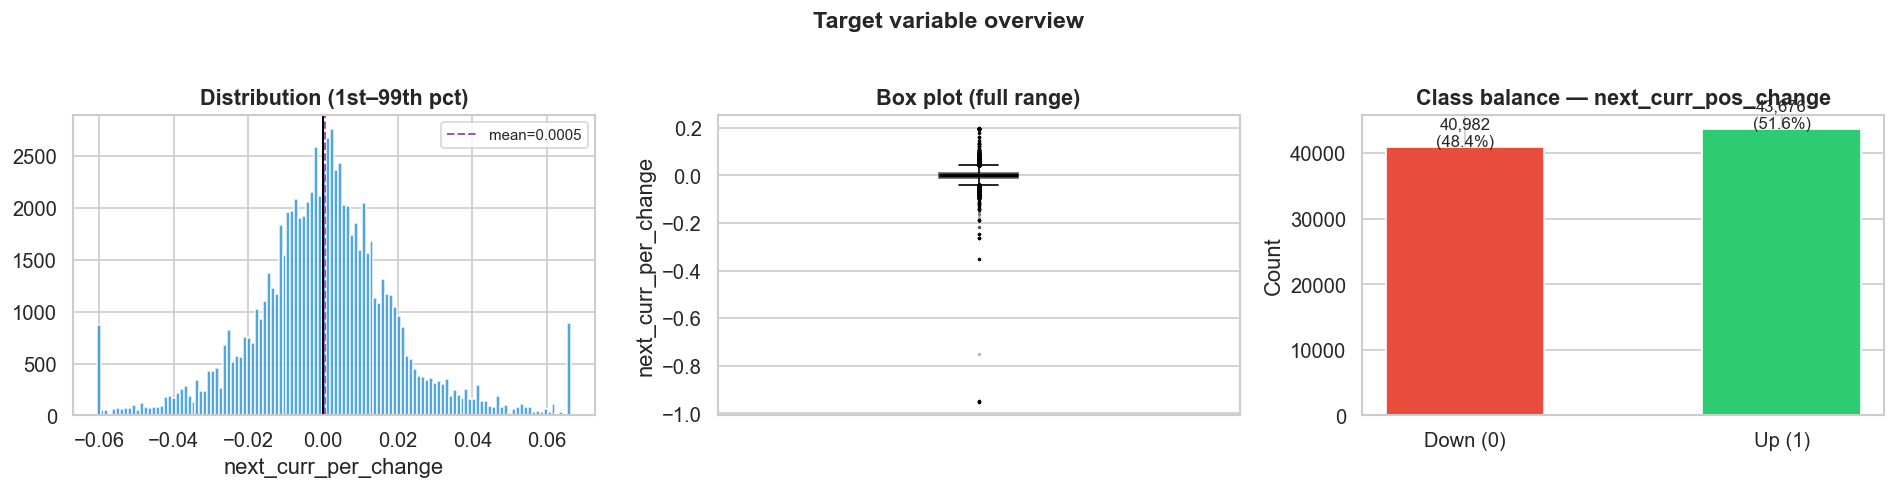

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 1. full distribution (winsorised for visibility) ─────────────────────────
clip_lo, clip_hi = target.quantile(0.01), target.quantile(0.99)
clipped = target.clip(clip_lo, clip_hi)
axes[0].hist(clipped, bins=120, color=C_NEUTRAL, edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1.2)
axes[0].axvline(clipped.mean(), color=C_ACCENT, linestyle='--', linewidth=1.2, label=f'mean={clipped.mean():.4f}')
axes[0].set_title('Distribution (1st–99th pct)')
axes[0].set_xlabel('next_curr_per_change')
axes[0].legend(fontsize=9)

# ── 2. box-plot with outlier markers ─────────────────────────────────────────
axes[1].boxplot(target, vert=True, patch_artist=True,
                boxprops=dict(facecolor=C_NEUTRAL, alpha=0.6),
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3, color=C_NEG))
axes[1].set_title('Box plot (full range)')
axes[1].set_ylabel('next_curr_per_change')
axes[1].set_xticks([])

# ── 3. binary class balance ───────────────────────────────────────────────────
vc = df['next_curr_pos_change'].value_counts()
axes[2].bar(['Down (0)', 'Up (1)'], [vc.get(0, 0), vc.get(1, 0)],
            color=[C_NEG, C_POS], edgecolor='white', width=0.5)
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    axes[2].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[2].set_title('Class balance — next_curr_pos_change')
axes[2].set_ylabel('Count')

plt.suptitle('Target variable overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Outlier analysis
for pct in [1, 5, 10, 20, 25, 50]:
    thr = pct / 100
    n_above = (target.abs() > thr).sum()
    print(f'|change| > {pct:>2}%  → {n_above:>5} rows  ({n_above/len(target)*100:.2f}%)')

|change| >  1%  → 43999 rows  (51.97%)
|change| >  5%  →  3145 rows  (3.71%)
|change| > 10%  →   412 rows  (0.49%)
|change| > 20%  →    57 rows  (0.07%)
|change| > 25%  →    44 rows  (0.05%)
|change| > 50%  →    20 rows  (0.02%)


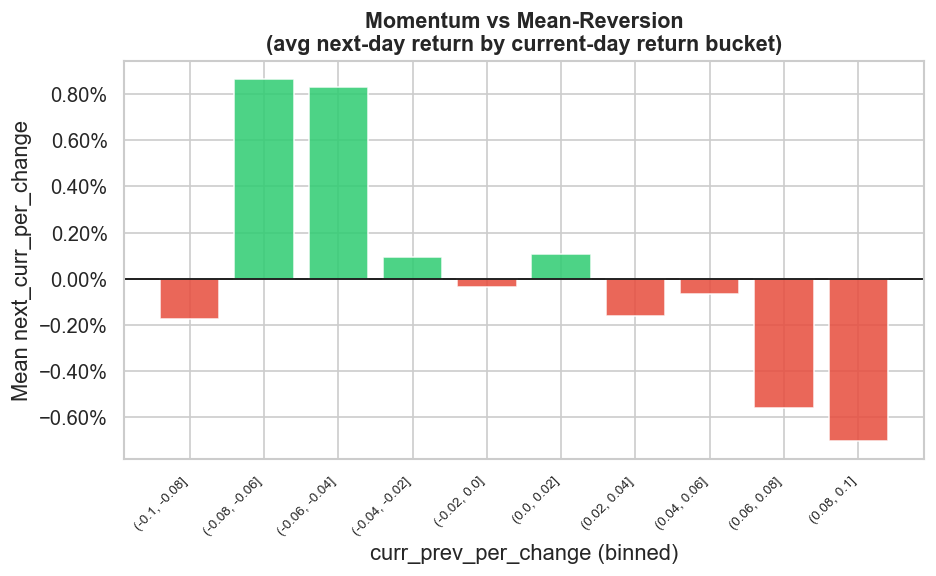


Table:
                         mean   median  count
curr_prev_per_change                         
(-0.1, -0.08]        -0.00175 -0.00536    555
(-0.08, -0.06]        0.00866  0.00262    590
(-0.06, -0.04]        0.00833  0.00453   1836
(-0.04, -0.02]        0.00095  0.00112   7919
(-0.02, 0.0]         -0.00036  0.00039  31079
(0.0, 0.02]           0.00107  0.00123  32262
(0.02, 0.04]         -0.00162 -0.00109   7408
(0.04, 0.06]         -0.00068  0.00107   1744
(0.06, 0.08]         -0.00561 -0.00277    769
(0.08, 0.1]          -0.00704  0.00176    496


In [14]:
# Momentum vs mean-reversion: does yesterday's move predict tomorrow's direction?
fig, ax = plt.subplots(figsize=(8, 5))

curr_bins = pd.cut(df['curr_prev_per_change'].clip(-0.1, 0.1), bins=10)
grouped = df.groupby(curr_bins, observed=False)['next_curr_per_change'].agg(['mean', 'median', 'count'])

bar_colors = [C_POS if v >= 0 else C_NEG for v in grouped['mean']]
ax.bar(range(len(grouped)), grouped['mean'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(grouped)))
ax.set_xticklabels([str(x) for x in grouped.index], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('curr_prev_per_change (binned)')
ax.set_ylabel('Mean next_curr_per_change')
ax.set_title('Momentum vs Mean-Reversion\n(avg next-day return by current-day return bucket)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
plt.tight_layout()
plt.show()
print('\nTable:')
print(grouped.round(5))

## 4. Temporal patterns

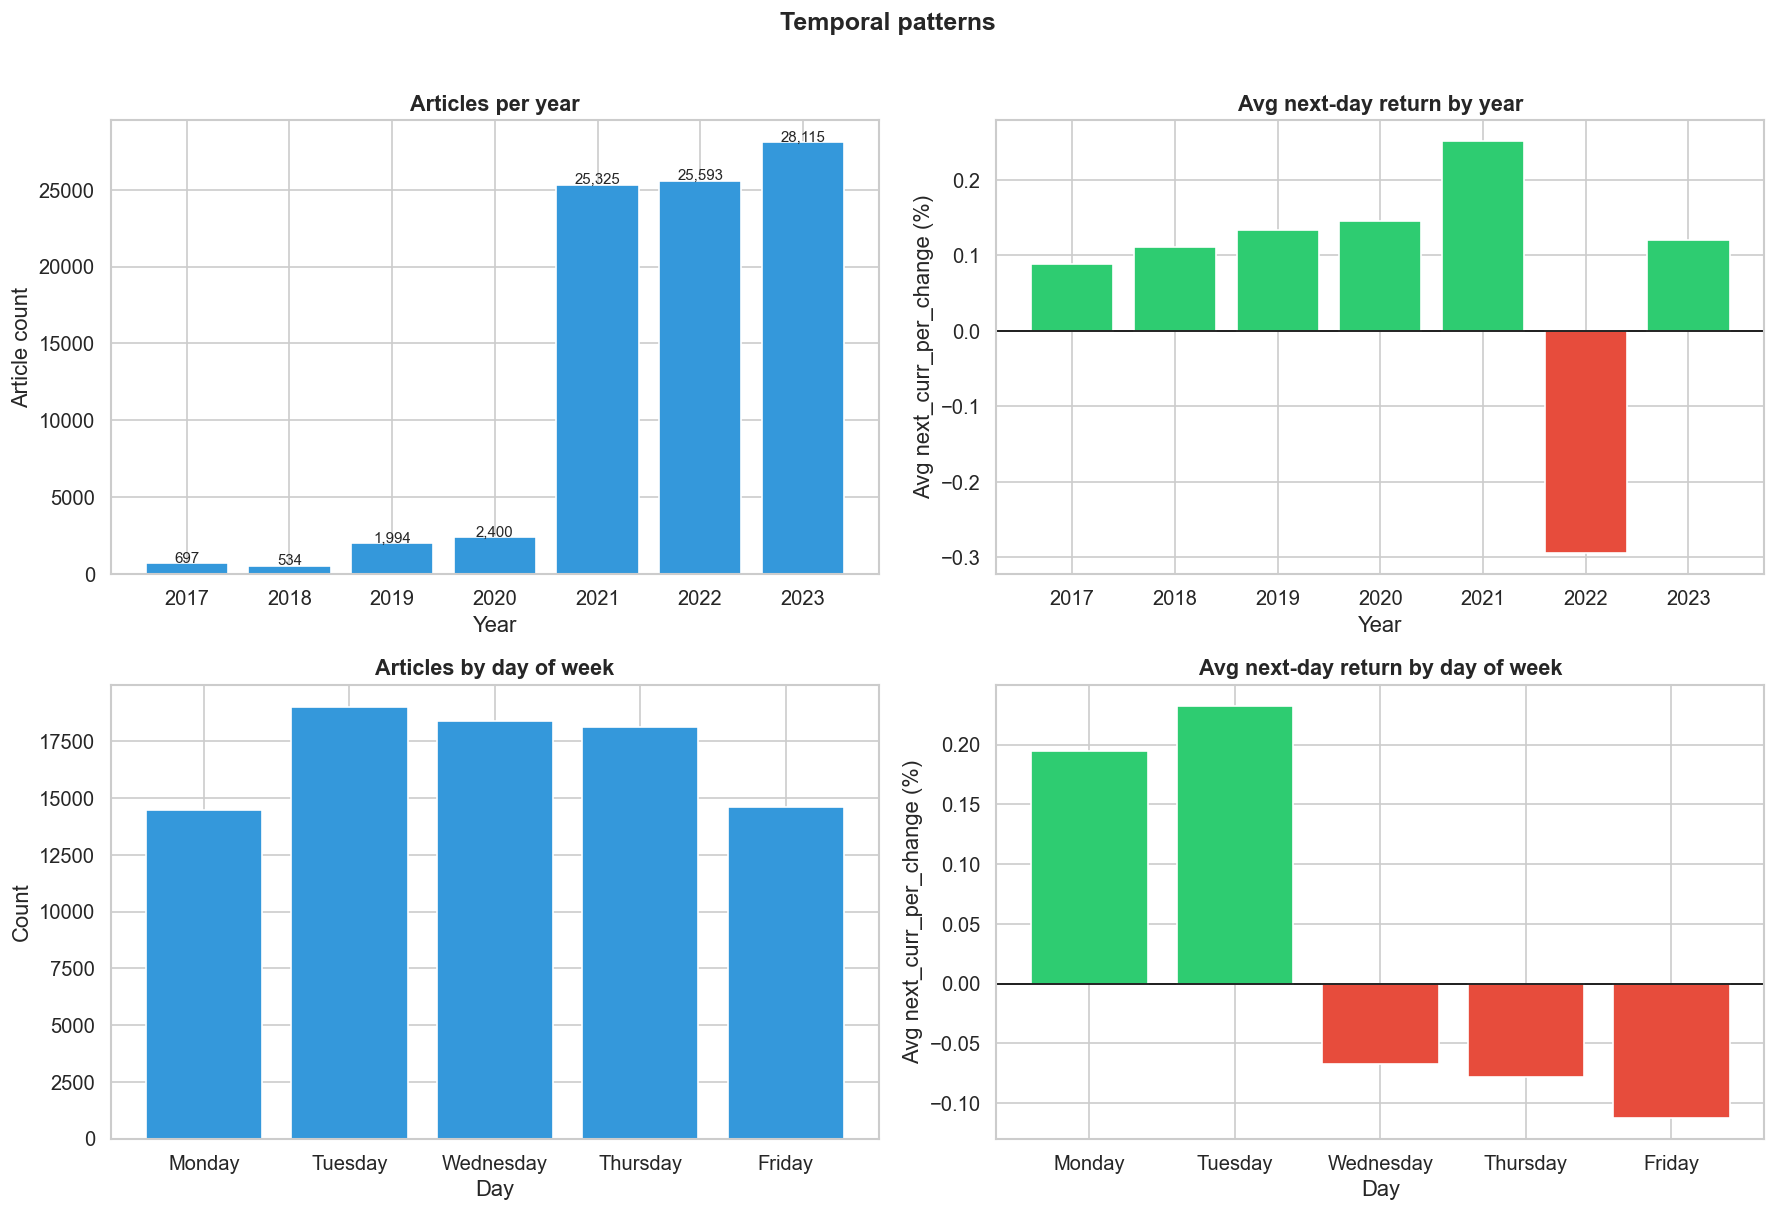

In [15]:
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dow']   = df['date'].dt.day_name()

DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── articles per year ─────────────────────────────────────────────────────────
year_counts = df.groupby('year').size()
axes[0, 0].bar(year_counts.index, year_counts.values, color=C_NEUTRAL, edgecolor='white')
axes[0, 0].set_title('Articles per year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Article count')
for x, v in zip(year_counts.index, year_counts.values):
    axes[0, 0].text(x, v + 50, f'{v:,}', ha='center', fontsize=9)

# ── avg target by year ────────────────────────────────────────────────────────
year_target = df.groupby('year')['next_curr_per_change'].mean()
bar_colors  = [C_POS if v >= 0 else C_NEG for v in year_target]
axes[0, 1].bar(year_target.index, year_target.values * 100, color=bar_colors, edgecolor='white')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Avg next-day return by year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Avg next_curr_per_change (%)')

# ── articles by day-of-week ───────────────────────────────────────────────────
dow_counts = df['dow'].value_counts().reindex(DOW_ORDER)
axes[1, 0].bar(DOW_ORDER, dow_counts.values, color=C_NEUTRAL, edgecolor='white')
axes[1, 0].set_title('Articles by day of week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Count')

# ── avg target by day-of-week ─────────────────────────────────────────────────
dow_target = df.groupby('dow')['next_curr_per_change'].mean().reindex(DOW_ORDER)
bar_colors  = [C_POS if v >= 0 else C_NEG for v in dow_target]
axes[1, 1].bar(DOW_ORDER, dow_target.values * 100, color=bar_colors, edgecolor='white')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Avg next-day return by day of week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Avg next_curr_per_change (%)')

plt.suptitle('Temporal patterns', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

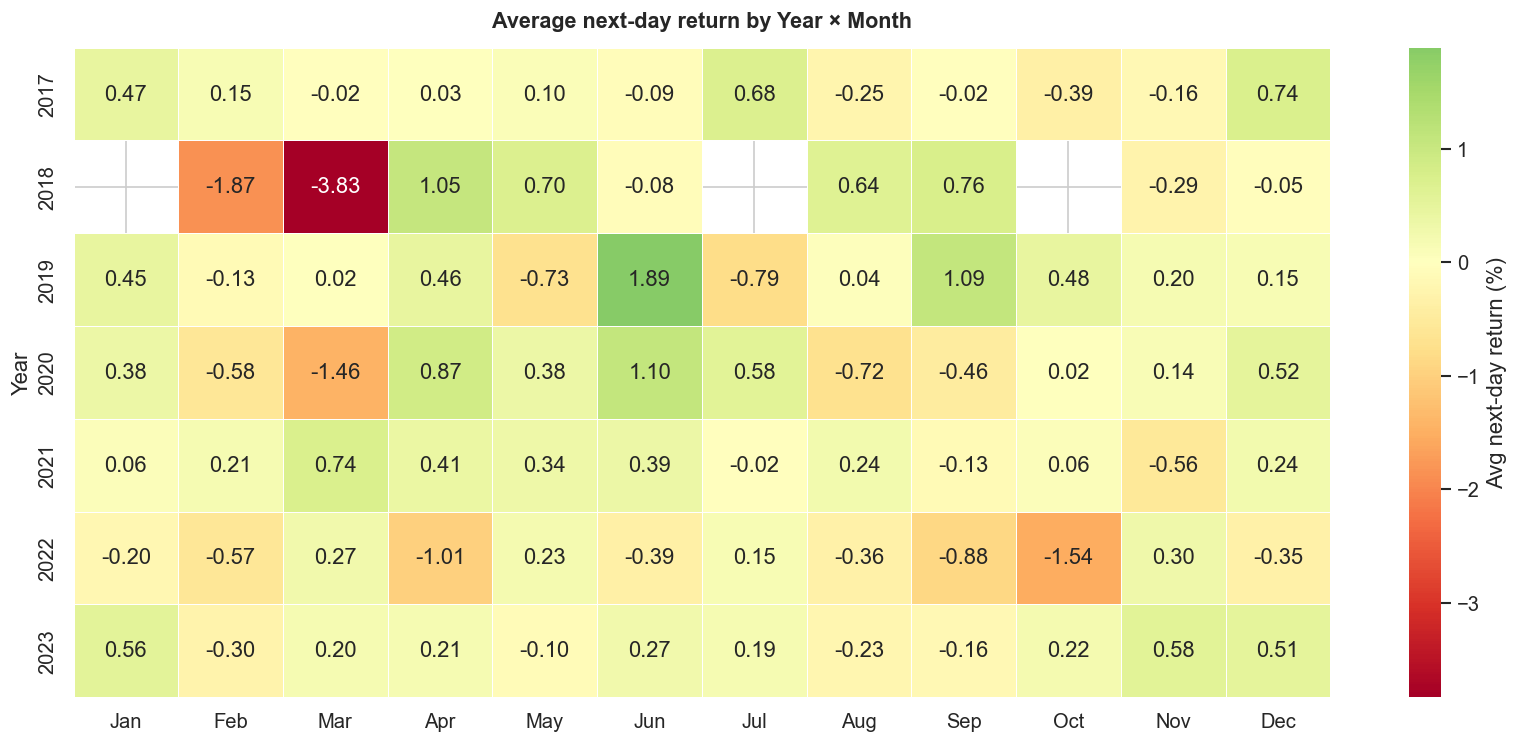

In [16]:
# Monthly heatmap of avg next-day return
pivot = df.pivot_table(values='next_curr_per_change', index='year', columns='month', aggfunc='mean')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, len(pivot) * 0.7 + 1.5))
sns.heatmap(
    pivot * 100,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Avg next-day return (%)'}
)
ax.set_title('Average next-day return by Year × Month', pad=12)
ax.set_ylabel('Year')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

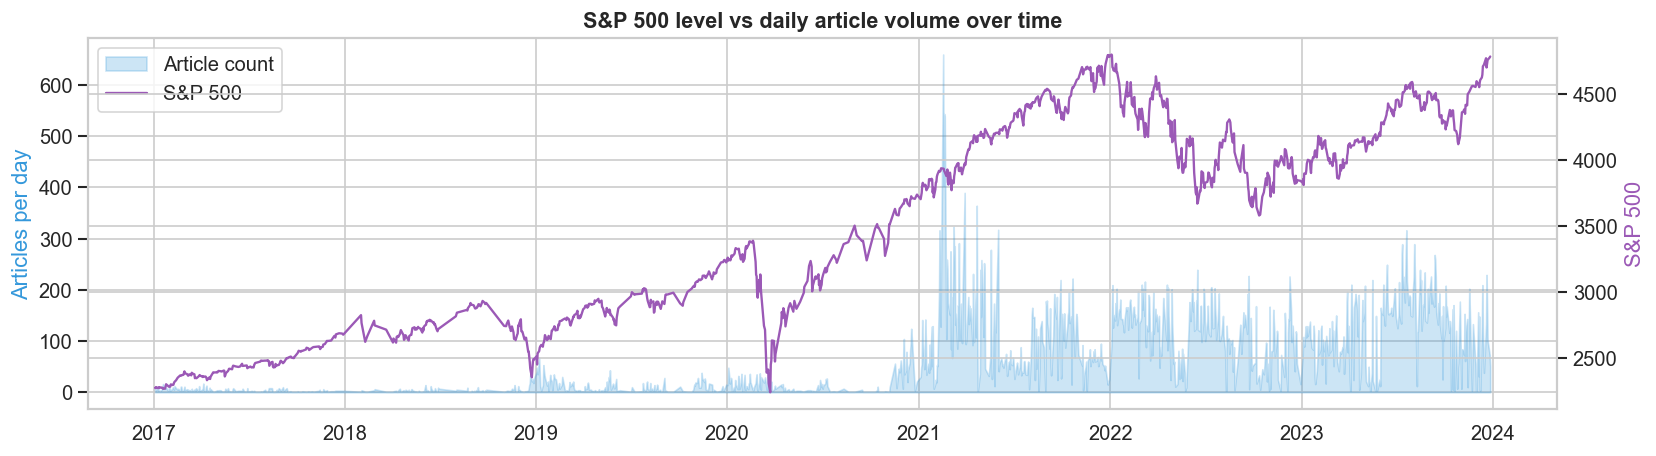

In [17]:
# S&P 500 index over time vs article volume
sp_daily = df.groupby('date').agg(sp500=('S&P500', 'first'), n_articles=('ticker', 'count')).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.fill_between(sp_daily['date'], sp_daily['n_articles'], alpha=0.25, color=C_NEUTRAL, label='Article count')
ax2.plot(sp_daily['date'], sp_daily['sp500'], color=C_ACCENT, linewidth=1.4, label='S&P 500')

ax1.set_ylabel('Articles per day', color=C_NEUTRAL)
ax2.set_ylabel('S&P 500', color=C_ACCENT)
ax1.set_xlabel('')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('S&P 500 level vs daily article volume over time')
plt.tight_layout()
plt.show()

## 5. Ticker & sector analysis

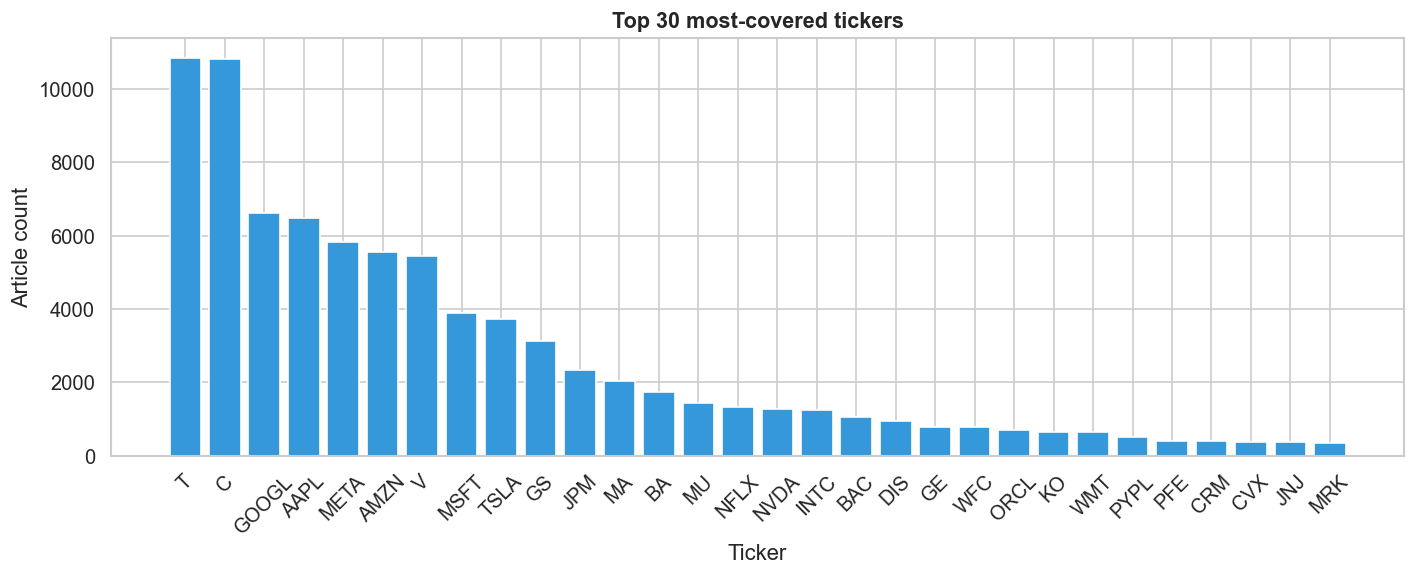

In [18]:
# Top-30 most-covered tickers
top_tickers = df['ticker'].value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_tickers.index, top_tickers.values, color=C_NEUTRAL, edgecolor='white')
ax.set_title('Top 30 most-covered tickers')
ax.set_xlabel('Ticker')
ax.set_ylabel('Article count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

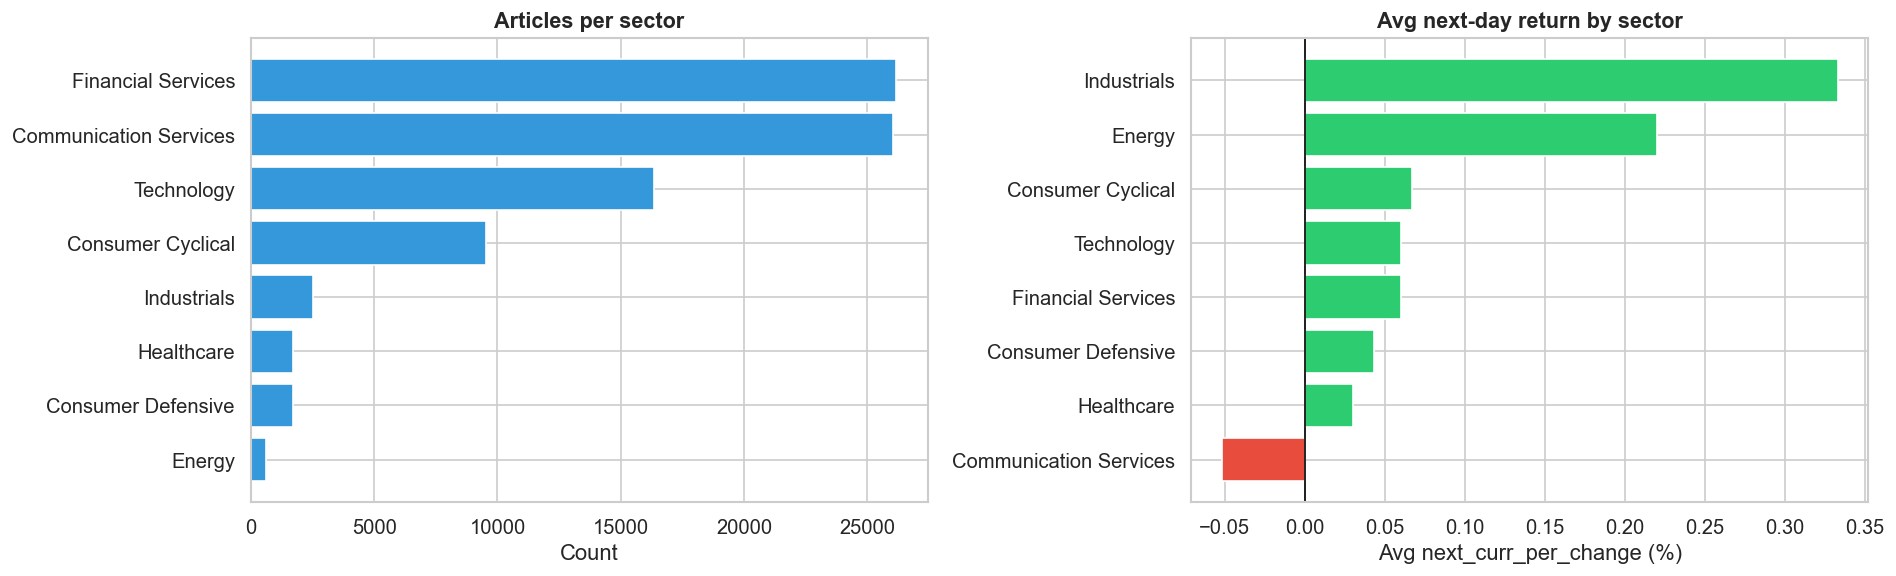


Sector stats:
                           mean      std  count
sector                                         
Communication Services -0.00052  0.03029  26050
Healthcare              0.00030  0.02121   1701
Consumer Defensive      0.00043  0.01167   1698
Financial Services      0.00060  0.01787  26163
Technology              0.00060  0.02205  16335
Consumer Cyclical       0.00067  0.04713   9547
Energy                  0.00220  0.01665    633
Industrials             0.00333  0.02407   2531


In [19]:
# Sector breakdown
if 'sector' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sector_counts = df.groupby('sector').size().sort_values(ascending=True)
    axes[0].barh(sector_counts.index, sector_counts.values, color=C_NEUTRAL, edgecolor='white')
    axes[0].set_title('Articles per sector')
    axes[0].set_xlabel('Count')

    sector_target = (
        df.groupby('sector')['next_curr_per_change']
        .agg(['mean', 'std', 'count'])
        .sort_values('mean')
    )
    bar_colors = [C_POS if v >= 0 else C_NEG for v in sector_target['mean']]
    axes[1].barh(sector_target.index, sector_target['mean'] * 100, color=bar_colors, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title('Avg next-day return by sector')
    axes[1].set_xlabel('Avg next_curr_per_change (%)')

    plt.tight_layout()
    plt.show()
    print('\nSector stats:')
    print(sector_target.round(5))

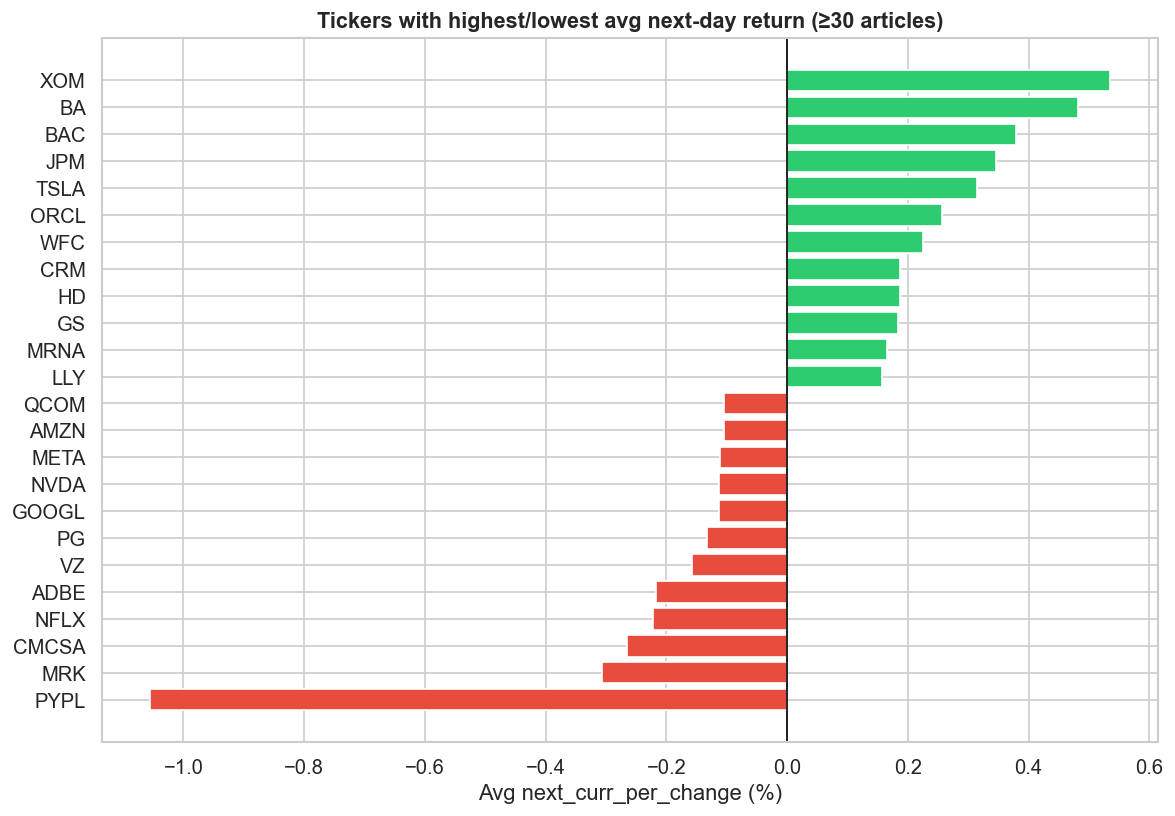

In [20]:
# Tickers with highest/lowest average next-day return (min 30 articles)
ticker_stats = (
    df.groupby('ticker')['next_curr_per_change']
    .agg(['mean', 'std', 'count'])
    .query('count >= 30')
    .sort_values('mean')
)

top_n = 12
tail_tickers = ticker_stats.head(top_n)
head_tickers = ticker_stats.tail(top_n)
extreme_tickers = pd.concat([tail_tickers, head_tickers])

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [C_POS if v >= 0 else C_NEG for v in extreme_tickers['mean']]
ax.barh(extreme_tickers.index, extreme_tickers['mean'] * 100, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Avg next_curr_per_change (%)')
ax.set_title(f'Tickers with highest/lowest avg next-day return (≥30 articles)')
plt.tight_layout()
plt.show()

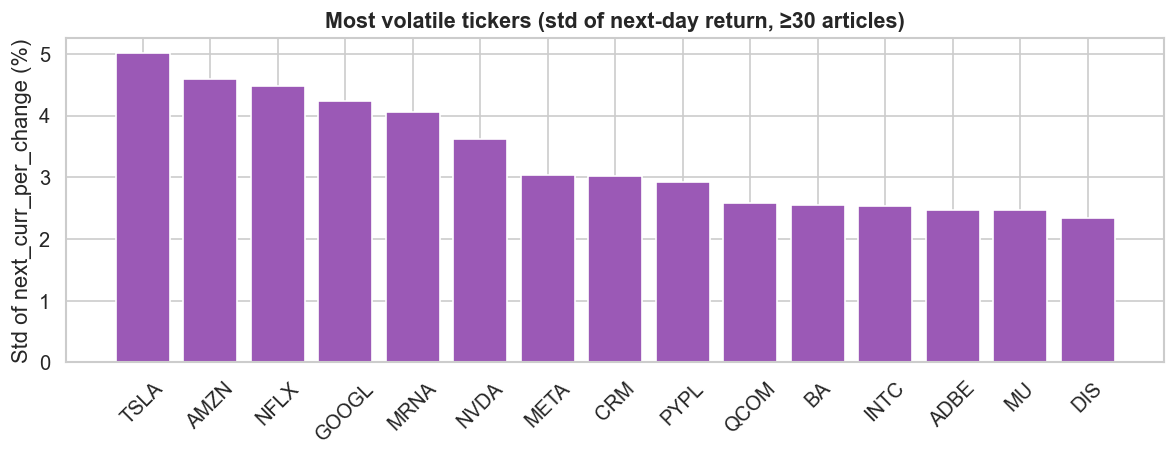

In [21]:
# Tickers with highest volatility in next-day return (most unpredictable)
most_volatile = ticker_stats.query('count >= 30').nlargest(15, 'std')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(most_volatile.index, most_volatile['std'] * 100, color=C_ACCENT, edgecolor='white')
ax.set_title('Most volatile tickers (std of next-day return, ≥30 articles)')
ax.set_ylabel('Std of next_curr_per_change (%)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Sentiment & emotion analysis

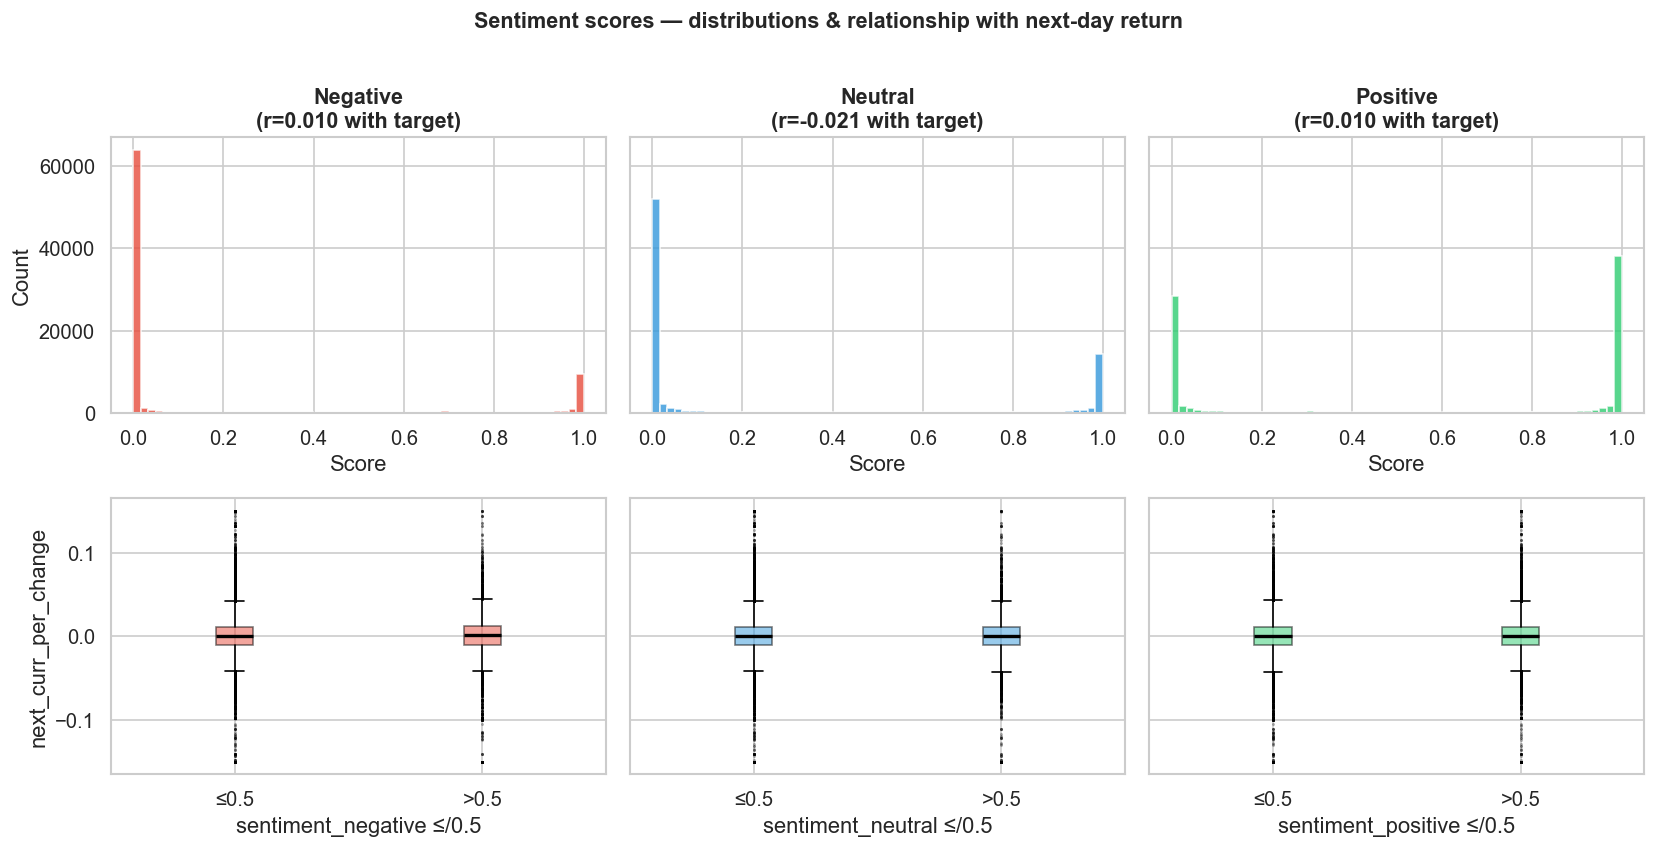

In [22]:
SENT_COLS    = ['sentiment_negative', 'sentiment_neutral', 'sentiment_positive']
EMOTION_COLS = ['emotion_anger', 'emotion_fear', 'emotion_joy',
                'emotion_sadness', 'emotion_disgust', 'emotion_surprise', 'emotion_neutral']

sent_present    = [c for c in SENT_COLS    if c in df.columns]
emotion_present = [c for c in EMOTION_COLS if c in df.columns]

fig, axes = plt.subplots(2, len(sent_present), figsize=(14, 7), sharey='row')
if len(sent_present) == 1:
    axes = axes.reshape(-1, 1)

COLORS_SENT = [C_NEG, C_NEUTRAL, C_POS]
for i, col in enumerate(sent_present):
    axes[0, i].hist(df[col].dropna(), bins=60, color=COLORS_SENT[i], alpha=0.8, edgecolor='white')
    axes[0, i].set_title(col.replace('sentiment_', '').capitalize())
    axes[0, i].set_xlabel('Score')
    if i == 0:
        axes[0, i].set_ylabel('Count')

    # correlation with target
    corr = df[col].corr(df['next_curr_per_change'])
    axes[0, i].set_title(f'{col.replace("sentiment_","").capitalize()}\n(r={corr:.3f} with target)')

    # box plot: target distribution by sentiment dominance
    dom_col = f'dominant_sent_{col}'
    threshold = 0.5
    high = df.loc[df[col] > threshold, 'next_curr_per_change'].clip(-0.15, 0.15)
    low  = df.loc[df[col] <= threshold, 'next_curr_per_change'].clip(-0.15, 0.15)
    axes[1, i].boxplot([low.dropna(), high.dropna()], patch_artist=True,
                       boxprops=dict(facecolor=COLORS_SENT[i], alpha=0.5),
                       medianprops=dict(color='black', linewidth=2),
                       flierprops=dict(marker='.', markersize=1.5, alpha=0.3))
    axes[1, i].set_xticks([1, 2])
    axes[1, i].set_xticklabels([f'≤{threshold}', f'>{threshold}'])
    axes[1, i].set_xlabel(f'{col} ≤/{threshold}')
    if i == 0:
        axes[1, i].set_ylabel('next_curr_per_change')

plt.suptitle('Sentiment scores — distributions & relationship with next-day return', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

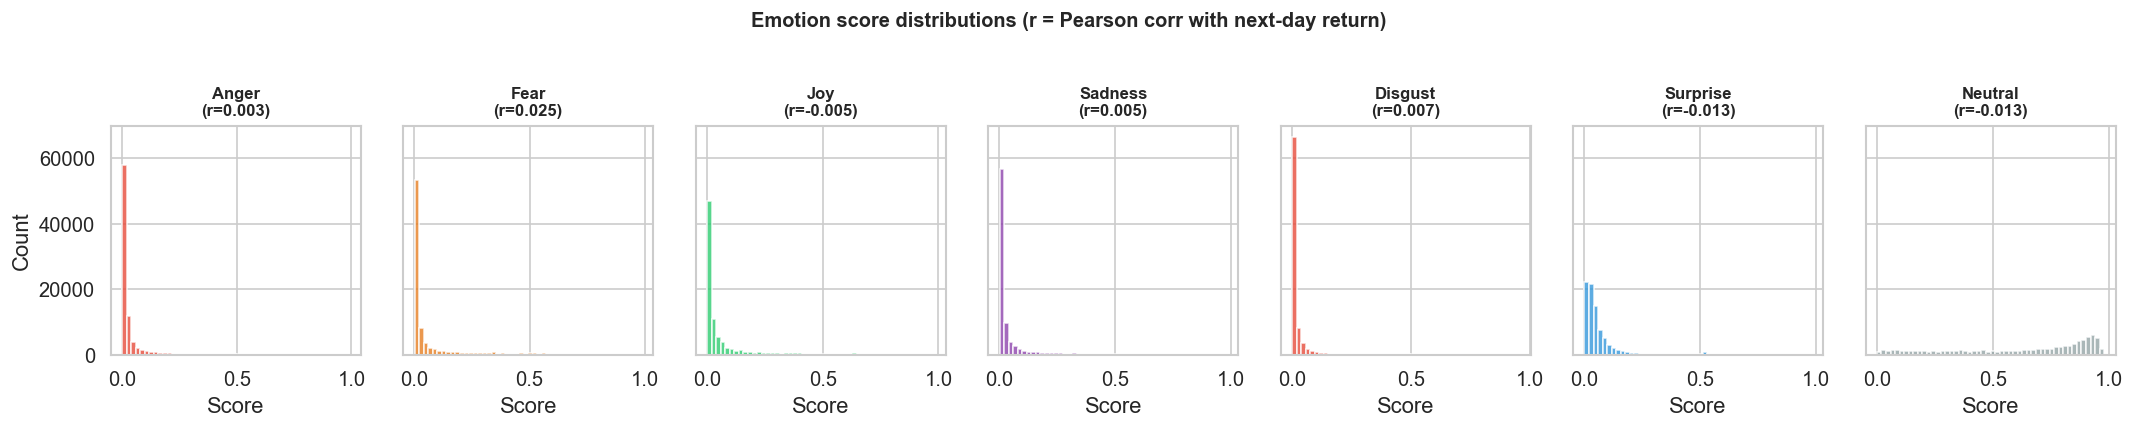

In [23]:
# Emotion distributions
fig, axes = plt.subplots(1, len(emotion_present), figsize=(18, 3.5), sharey=True)
emo_colors = [C_NEG, '#e67e22', C_POS, '#8e44ad', C_NEG, C_NEUTRAL, '#95a5a6']
for i, col in enumerate(emotion_present):
    axes[i].hist(df[col].dropna(), bins=50, color=emo_colors[i], alpha=0.8, edgecolor='white')
    corr = df[col].corr(df['next_curr_per_change'])
    axes[i].set_title(f"{col.replace('emotion_','').capitalize()}\n(r={corr:.3f})", fontsize=10)
    axes[i].set_xlabel('Score')
axes[0].set_ylabel('Count')
plt.suptitle('Emotion score distributions (r = Pearson corr with next-day return)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

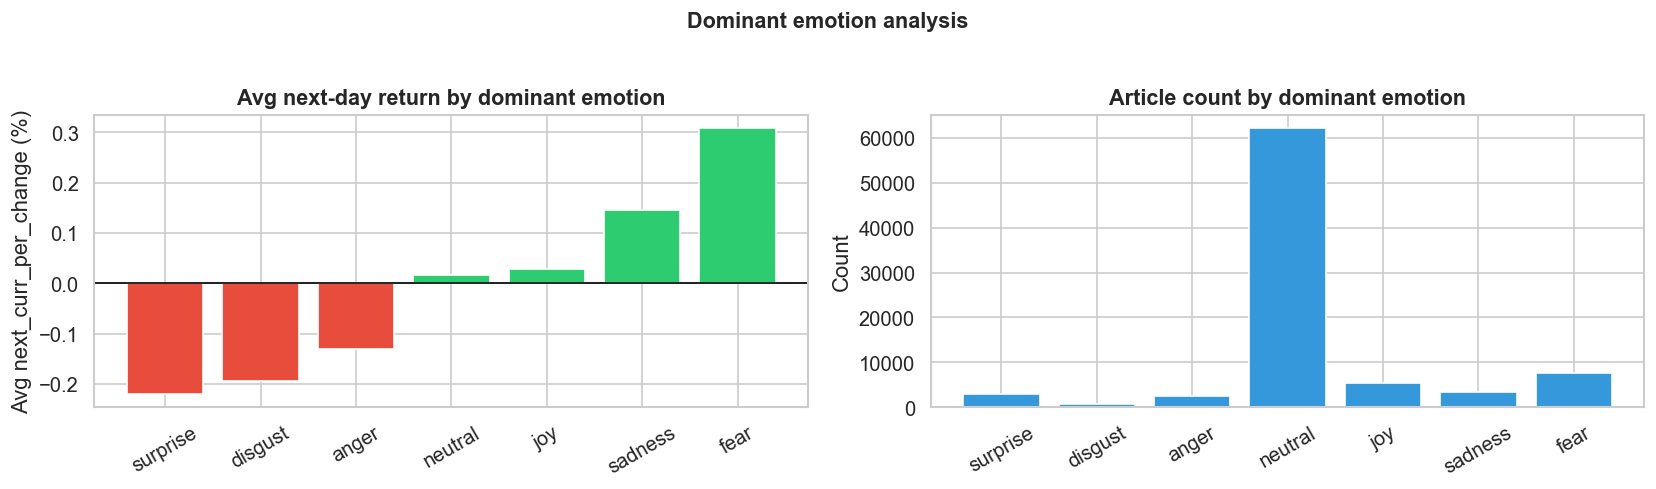

                     mean      std  count
dominant_emotion                         
surprise         -0.00220  0.02311   2982
disgust          -0.00193  0.02883    673
anger            -0.00131  0.02955   2616
neutral           0.00017  0.02649  62100
joy               0.00029  0.02131   5298
sadness           0.00146  0.03505   3426
fear              0.00309  0.03517   7563


In [24]:
# Dominant emotion per article → avg next-day return
if emotion_present:
    df['dominant_emotion'] = df[emotion_present].idxmax(axis=1).str.replace('emotion_', '')

    emo_target = (
        df.groupby('dominant_emotion')['next_curr_per_change']
        .agg(['mean', 'std', 'count'])
        .sort_values('mean')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    bar_colors = [C_POS if v >= 0 else C_NEG for v in emo_target['mean']]
    axes[0].bar(emo_target.index, emo_target['mean'] * 100, color=bar_colors, edgecolor='white')
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Avg next-day return by dominant emotion')
    axes[0].set_ylabel('Avg next_curr_per_change (%)')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(emo_target.index, emo_target['count'], color=C_NEUTRAL, edgecolor='white')
    axes[1].set_title('Article count by dominant emotion')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle('Dominant emotion analysis', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(emo_target.round(5))

Win rate (% next-day up) by dominant sentiment:
                    win_rate  count  win_rate_pct
dominant_sentiment                               
negative            0.540182  15243         54.02
neutral             0.502182  21996         50.22
positive            0.514477  47419         51.45


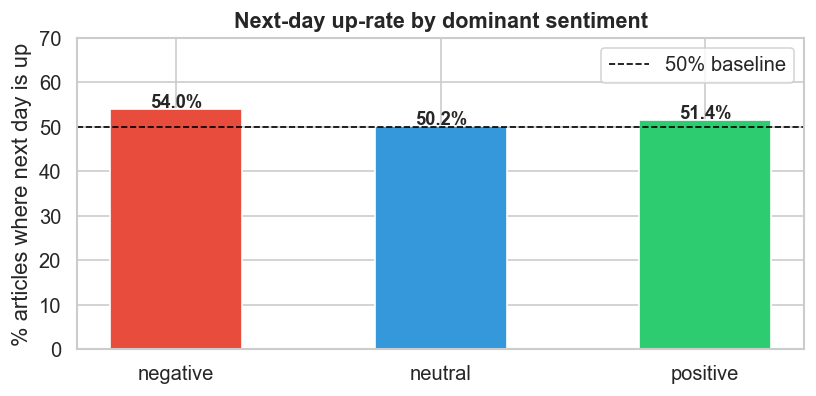

In [25]:
# Dominant sentiment → win-rate (% of articles where next day is up)
if sent_present:
    df['dominant_sentiment'] = df[sent_present].idxmax(axis=1).str.replace('sentiment_', '')
    sent_winrate = (
        df.groupby('dominant_sentiment')['next_curr_pos_change']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'win_rate'})
    )
    print('Win rate (% next-day up) by dominant sentiment:')
    sent_winrate['win_rate_pct'] = (sent_winrate['win_rate'] * 100).round(2)
    print(sent_winrate)

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(sent_winrate.index, sent_winrate['win_rate'] * 100,
                  color=[C_NEG, C_NEUTRAL, C_POS], edgecolor='white', width=0.5)
    ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
    for bar, val in zip(bars, sent_winrate['win_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val*100:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('% articles where next day is up')
    ax.set_title('Next-day up-rate by dominant sentiment')
    ax.set_ylim(0, 70)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Text-length signals

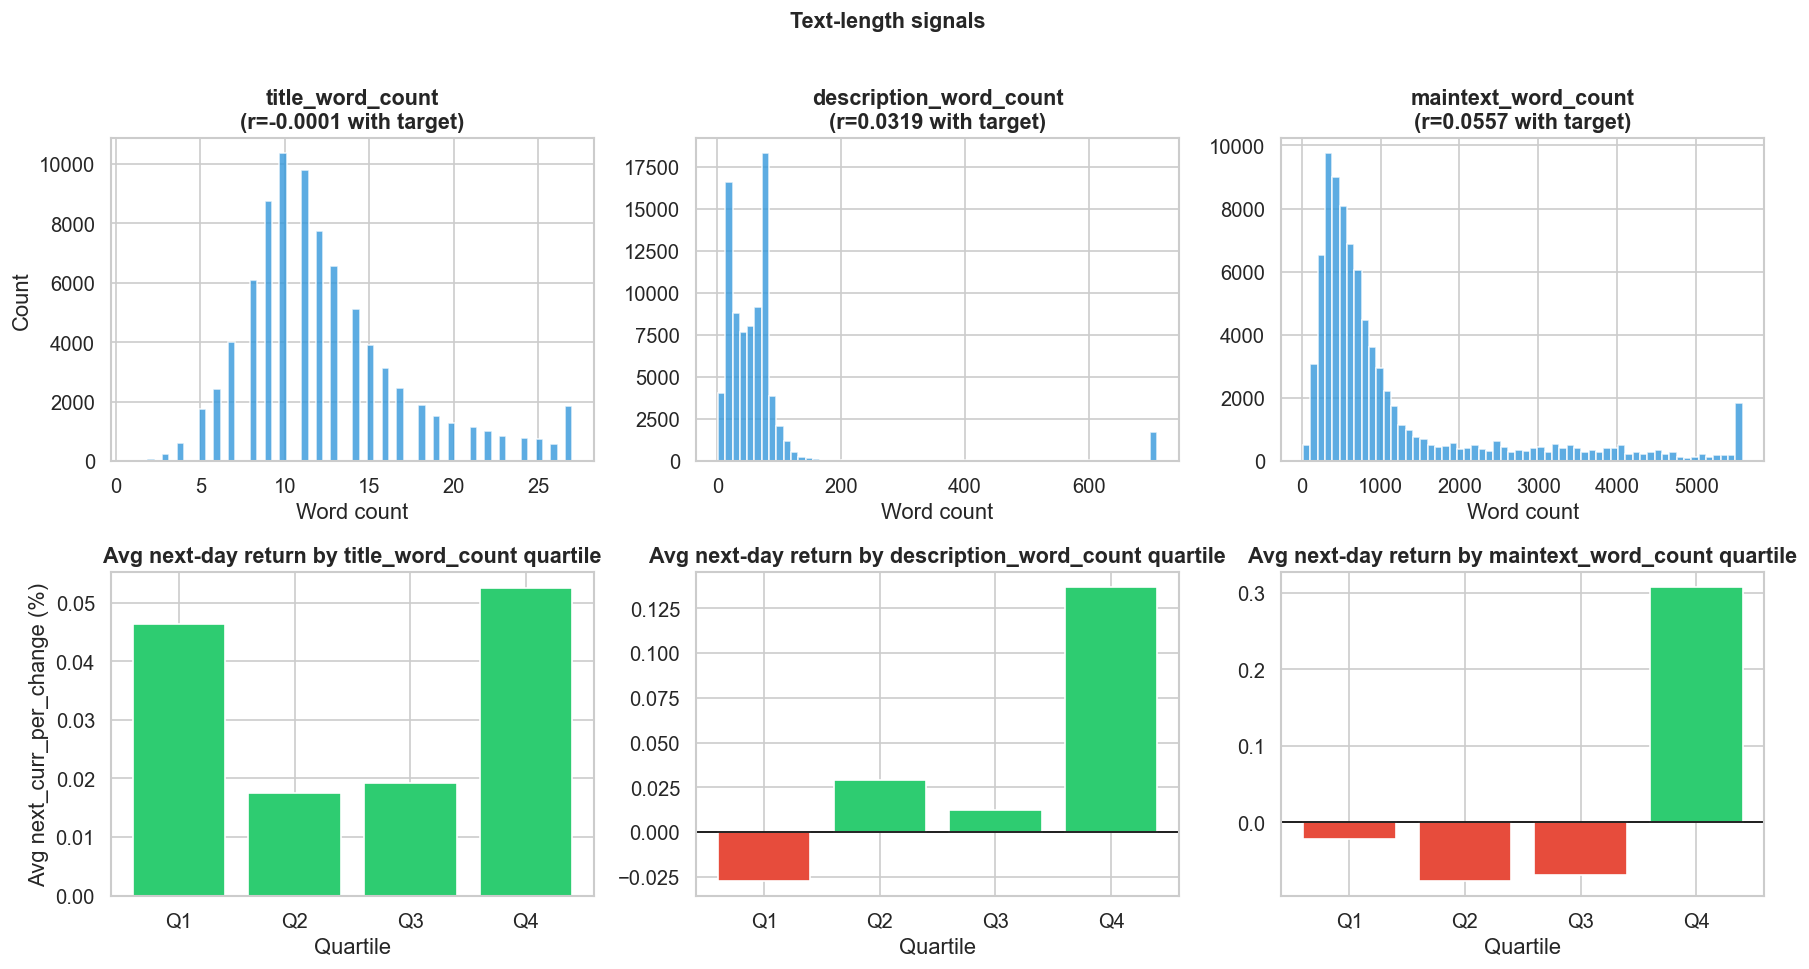

In [26]:
text_len_cols = [c for c in ['title_word_count', 'description_word_count', 'maintext_word_count'] if c in df.columns]

if text_len_cols:
    fig, axes = plt.subplots(2, len(text_len_cols), figsize=(15, 8))
    if len(text_len_cols) == 1:
        axes = axes.reshape(-1, 1)

    for i, col in enumerate(text_len_cols):
        col_data = df[col].clip(0, df[col].quantile(0.98))

        axes[0, i].hist(col_data, bins=60, color=C_NEUTRAL, alpha=0.8, edgecolor='white')
        corr = df[col].corr(df['next_curr_per_change'])
        axes[0, i].set_title(f'{col}\n(r={corr:.4f} with target)')
        axes[0, i].set_xlabel('Word count')
        if i == 0:
            axes[0, i].set_ylabel('Count')

        # avg return by word-count quartile
        df[f'{col}_q'] = pd.qcut(df[col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
        q_target = df.groupby(f'{col}_q', observed=True)['next_curr_per_change'].mean()
        bar_c = [C_POS if v >= 0 else C_NEG for v in q_target]
        axes[1, i].bar(q_target.index.astype(str), q_target.values * 100, color=bar_c, edgecolor='white')
        axes[1, i].axhline(0, color='black', linewidth=1)
        axes[1, i].set_title(f'Avg next-day return by {col} quartile')
        axes[1, i].set_xlabel('Quartile')
        if i == 0:
            axes[1, i].set_ylabel('Avg next_curr_per_change (%)')

    plt.suptitle('Text-length signals', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## 8. Price feature correlations

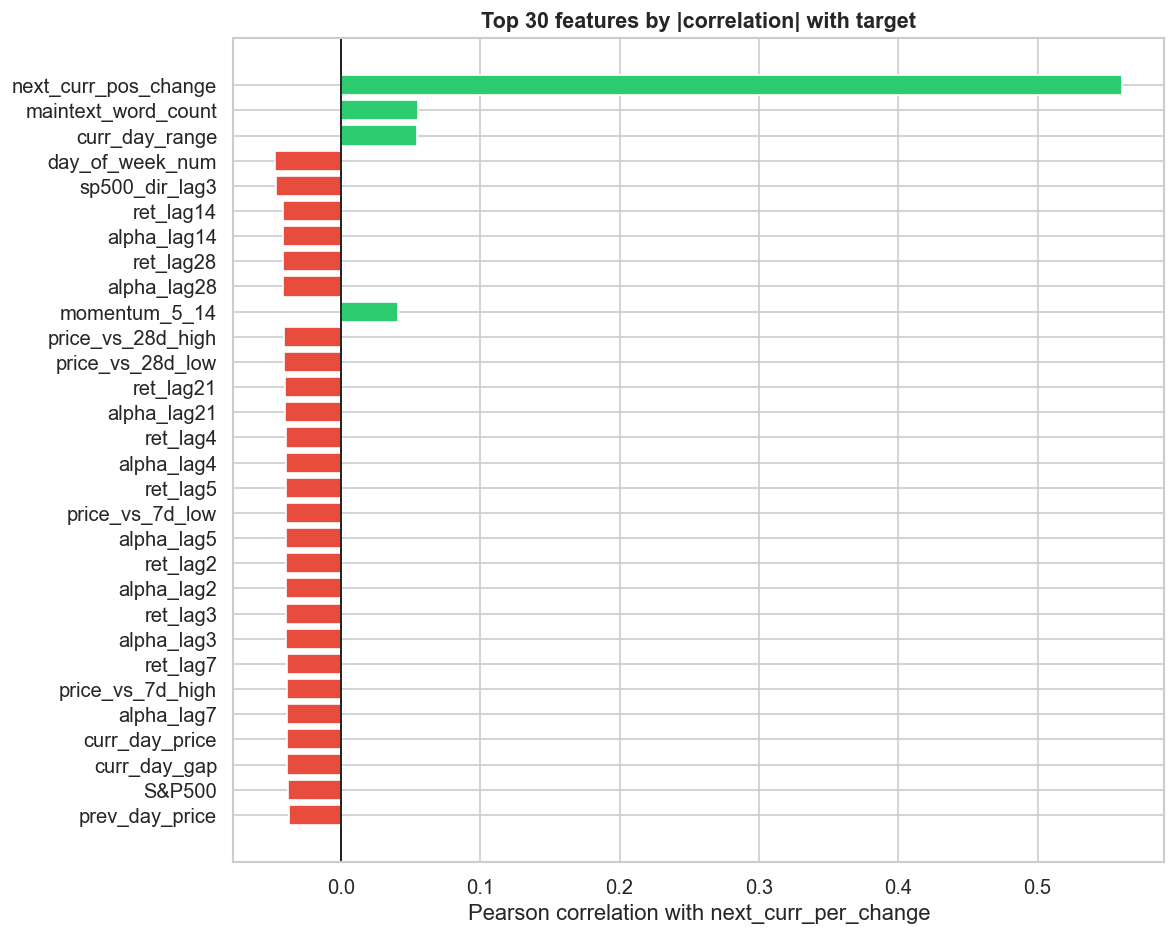

In [27]:
# All numeric features correlated with the target
num_cols = df.select_dtypes(include='number').columns.tolist()
target_corrs = (
    df[num_cols].corr()['next_curr_per_change']
    .drop('next_curr_per_change')
    .sort_values(key=abs, ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [C_POS if v >= 0 else C_NEG for v in target_corrs.values]
ax.barh(target_corrs.index[::-1], target_corrs.values[::-1], color=bar_colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Pearson correlation with next_curr_per_change')
ax.set_title('Top 30 features by |correlation| with target')
plt.tight_layout()
plt.show()

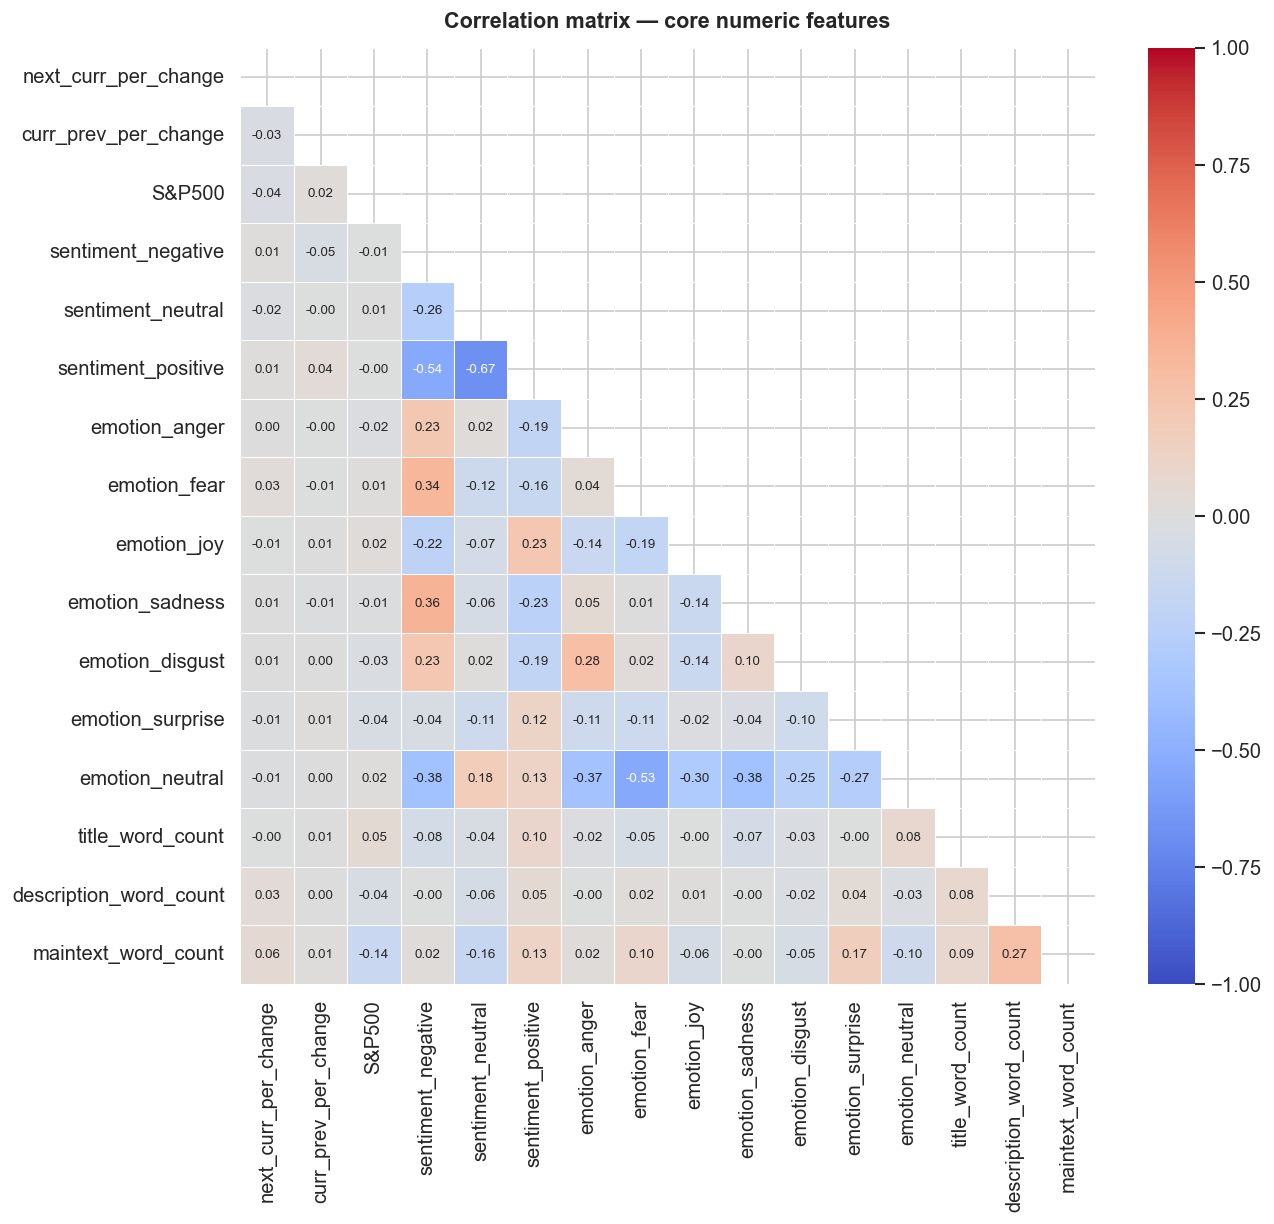

In [28]:
# Correlation heatmap for core numeric features
core_num = [
    'next_curr_per_change', 'curr_prev_per_change', 'S&P500',
] + sent_present + emotion_present + [c for c in text_len_cols if c in df.columns]
core_num = [c for c in core_num if c in df.columns]

corr_matrix = df[core_num].corr()

fig, ax = plt.subplots(figsize=(max(8, len(core_num) * 0.7), max(6, len(core_num) * 0.65)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlation matrix — core numeric features', pad=12)
plt.tight_layout()
plt.show()

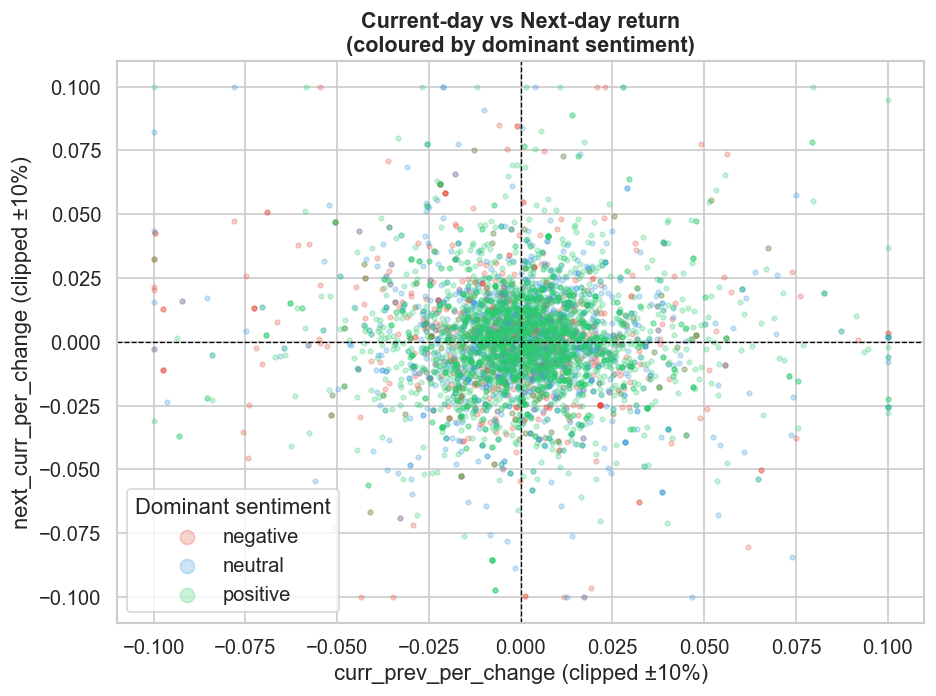

In [29]:
# Scatter: curr_day return vs next_day return, coloured by sentiment
sample = df.sample(min(5000, len(df)), random_state=42)

if 'dominant_sentiment' in sample.columns:
    sent_color_map = {'negative': C_NEG, 'neutral': C_NEUTRAL, 'positive': C_POS}
    fig, ax = plt.subplots(figsize=(8, 6))
    for sent, grp in sample.groupby('dominant_sentiment'):
        ax.scatter(
            grp['curr_prev_per_change'].clip(-0.1, 0.1),
            grp['next_curr_per_change'].clip(-0.1, 0.1),
            alpha=0.25, s=8,
            color=sent_color_map.get(sent, 'grey'),
            label=sent
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('curr_prev_per_change (clipped ±10%)')
    ax.set_ylabel('next_curr_per_change (clipped ±10%)')
    ax.set_title('Current-day vs Next-day return\n(coloured by dominant sentiment)')
    ax.legend(title='Dominant sentiment', markerscale=3)
    plt.tight_layout()
    plt.show()

## 9. Language & multi-article coverage

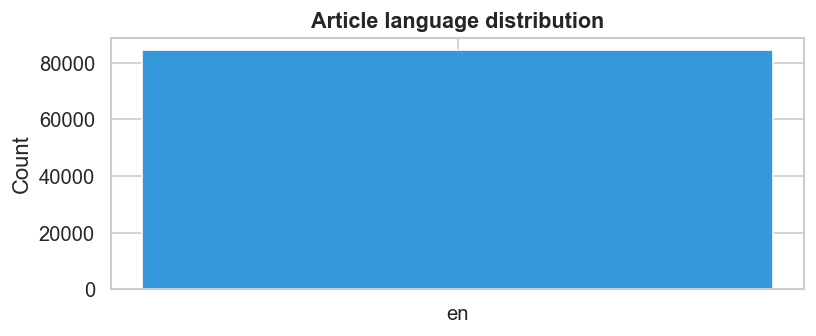

Articles per (ticker, date) pair:
1     6654
2     2787
3     1487
4      960
5      701
6      563
7      420
8      352
9      314
10     265
dtype: int64


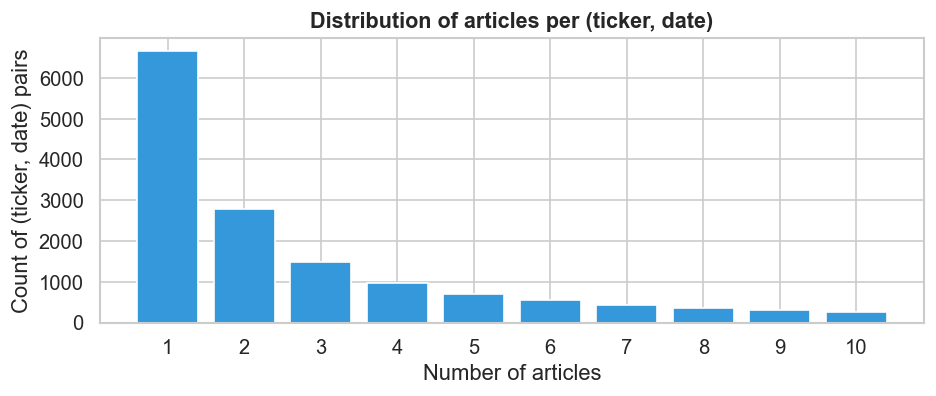

In [30]:
if 'language' in df.columns:
    lang_counts = df['language'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(lang_counts.index, lang_counts.values, color=C_NEUTRAL, edgecolor='white')
    ax.set_title('Article language distribution')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

# How many articles per (ticker, date) pair?
articles_per_event = df.groupby(['ticker', 'date']).size()
print('Articles per (ticker, date) pair:')
print(articles_per_event.value_counts().head(10))

fig, ax = plt.subplots(figsize=(8, 3.5))
vc = articles_per_event.value_counts().head(10).sort_index()
ax.bar(vc.index.astype(str), vc.values, color=C_NEUTRAL, edgecolor='white')
ax.set_title('Distribution of articles per (ticker, date)')
ax.set_xlabel('Number of articles')
ax.set_ylabel('Count of (ticker, date) pairs')
plt.tight_layout()
plt.show()

## 10. Key insights summary

In [31]:
print('=' * 65)
print('KEY INSIGHTS')
print('=' * 65)

# 1. class imbalance
up_pct = df['next_curr_pos_change'].mean() * 100
print(f'\n1. CLASS BALANCE')
print(f'   Next day goes UP  : {up_pct:.1f}%  (always-predict-up baseline accuracy)')
print(f'   Next day goes DOWN: {100-up_pct:.1f}%')

# 2. outliers in target
extreme_5 = (df['next_curr_per_change'].abs() > 0.05).mean() * 100
extreme_25 = (df['next_curr_per_change'].abs() > 0.25).mean() * 100
print(f'\n2. OUTLIERS IN TARGET')
print(f'   |change| > 5%  : {extreme_5:.1f}% of rows')
print(f'   |change| > 25% : {extreme_25:.2f}% of rows  (likely data errors)')

# 3. sentiment correlation
if 'sentiment_positive' in df.columns:
    r_pos = df['sentiment_positive'].corr(df['next_curr_per_change'])
    r_neg = df['sentiment_negative'].corr(df['next_curr_per_change'])
    print(f'\n3. SENTIMENT → TARGET CORRELATION')
    print(f'   Positive sentiment r = {r_pos:.4f}')
    print(f'   Negative sentiment r = {r_neg:.4f}')
    print(f'   (Very weak; sentiment alone is insufficient for prediction)')

# 4. momentum vs mean reversion
same_dir = (
    ((df['curr_prev_per_change'] > 0) & (df['next_curr_per_change'] > 0)) |
    ((df['curr_prev_per_change'] < 0) & (df['next_curr_per_change'] < 0))
).mean() * 100
print(f'\n4. MOMENTUM')
print(f'   Same direction today & tomorrow: {same_dir:.1f}%')
msg = 'slight momentum' if same_dir > 50 else 'slight mean-reversion'
print(f'   → Suggests {msg} tendency')

# 5. best/worst day-of-week
dow_winrate = df.groupby('dow')['next_curr_pos_change'].mean().reindex(DOW_ORDER)
best_day  = dow_winrate.idxmax()
worst_day = dow_winrate.idxmin()
print(f'\n5. DAY-OF-WEEK EFFECT')
print(f'   Best day for up-move : {best_day} ({dow_winrate[best_day]*100:.1f}% win rate)')
print(f'   Worst day for up-move: {worst_day} ({dow_winrate[worst_day]*100:.1f}% win rate)')

# 6. most articles
top_ticker = df['ticker'].value_counts().idxmax()
top_count  = df['ticker'].value_counts().max()
print(f'\n6. MOST-COVERED TICKER')
print(f'   {top_ticker}: {top_count:,} articles')

# 7. coverage per (ticker, date)
avg_articles = articles_per_event.mean()
print(f'\n7. MULTI-ARTICLE COVERAGE')
print(f'   Avg articles per (ticker, date): {avg_articles:.2f}')

print('\n' + '=' * 65)

KEY INSIGHTS

1. CLASS BALANCE
   Next day goes UP  : 51.6%  (always-predict-up baseline accuracy)
   Next day goes DOWN: 48.4%

2. OUTLIERS IN TARGET
   |change| > 5%  : 3.7% of rows
   |change| > 25% : 0.05% of rows  (likely data errors)

3. SENTIMENT → TARGET CORRELATION
   Positive sentiment r = 0.0104
   Negative sentiment r = 0.0103
   (Very weak; sentiment alone is insufficient for prediction)

4. MOMENTUM
   Same direction today & tomorrow: 50.3%
   → Suggests slight momentum tendency

5. DAY-OF-WEEK EFFECT
   Best day for up-move : Friday (55.2% win rate)
   Worst day for up-move: Thursday (47.8% win rate)

6. MOST-COVERED TICKER
   T: 10,862 articles

7. MULTI-ARTICLE COVERAGE
   Avg articles per (ticker, date): 5.06

